# Dataset description
## Medical complaints

**Source**: Supersalud

**Download**: [link](https://www.supersalud.gov.co/es-co/transparencia-y-acceso-a-la-informacion-publica/planeacion-presupuesto-e-informes/informes-trimestrales-sobre-acceso-a-informacion-quejas-y-reclamos#k=filename%3A%22RQ*%22#l=9226#s=151)

# Code
## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [2]:
path = "./data/nacional.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [3]:
df_f = df[
    ~(df["clasificacion"].str.lower().str.startswith("solicitud")) &
    ~(df["clasificacion"].str.lower().str.startswith("total")) &
    ~(df["anio"].eq(2026))
]
df_f.dropna(inplace=True)

total = (df_f
         .groupby(["anio", "clasificacion"])
         ["conteo"]
         .sum()
         .reset_index()
         [["anio", "conteo"]]
)

## Plot

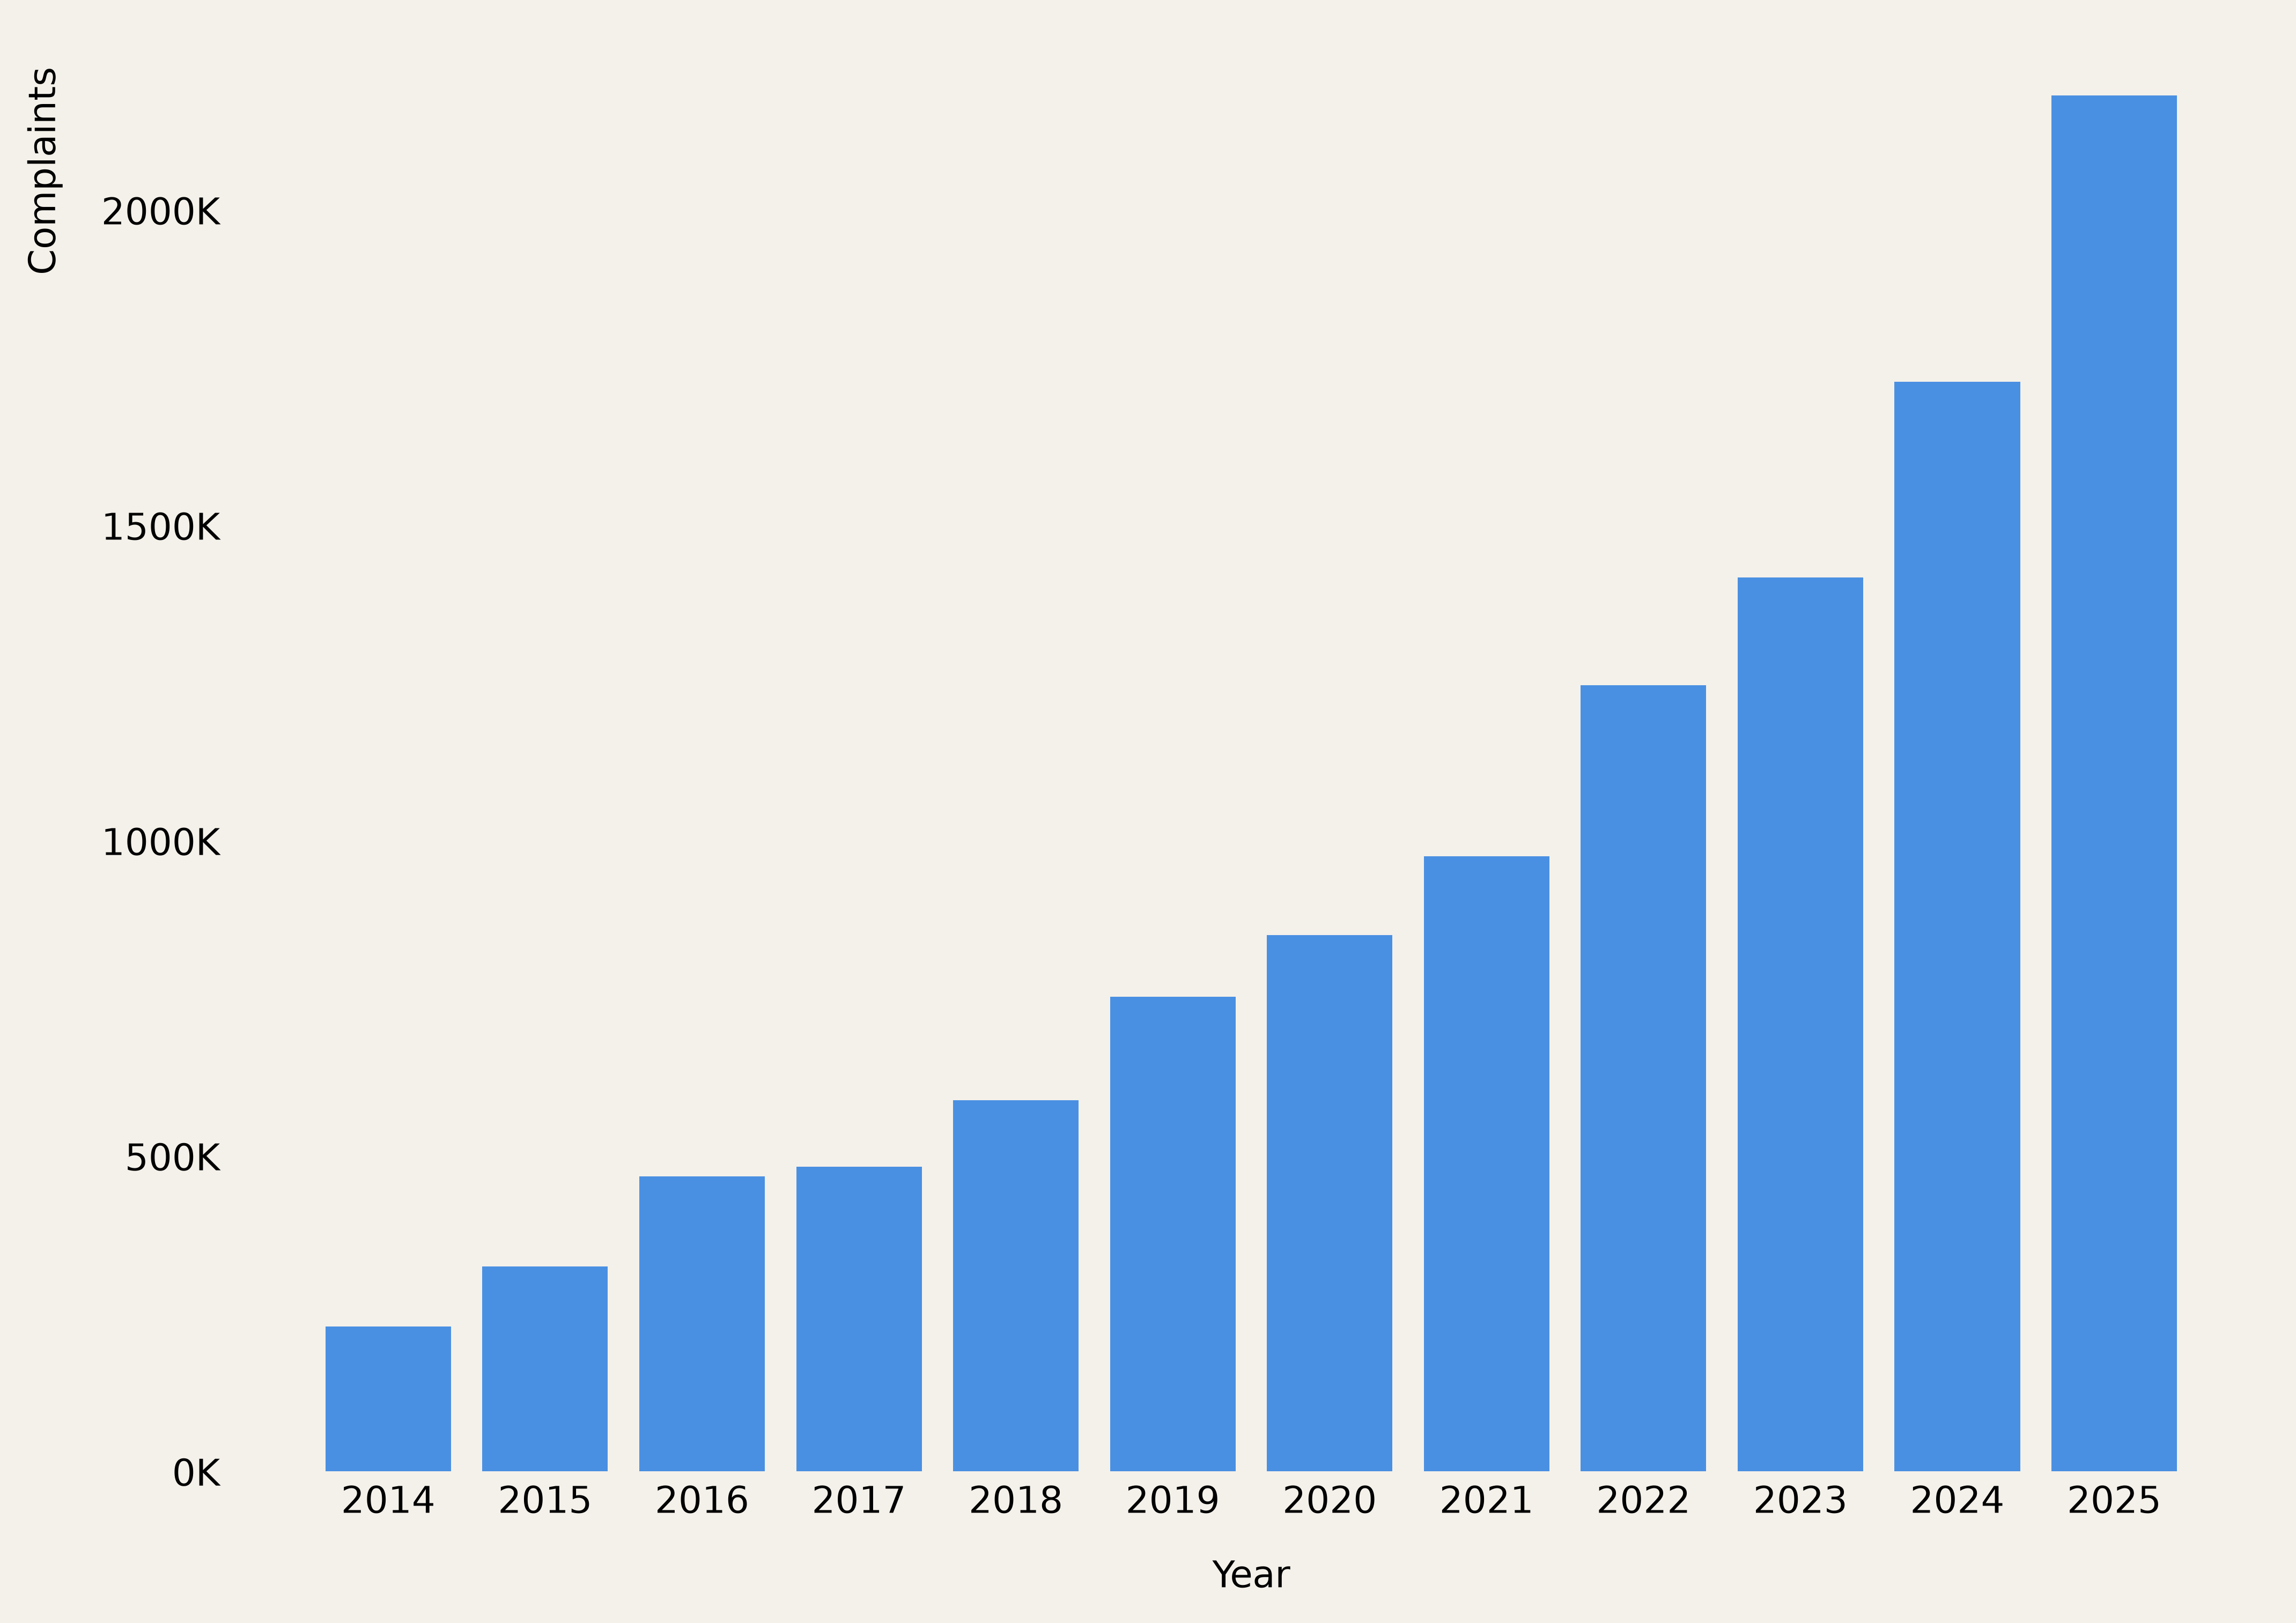

In [4]:
background = "#F4F1EA"
blue = "#4a90e2"
x_axis = total["anio"]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.bar(x_axis, total["conteo"], color=blue)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.xticks(x_axis, rotation=0)

plt.ylabel("Complaints", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()

## Complaint rate by department · 2025

## Load data

In [5]:
import json
import unicodedata
import matplotlib.cm as cm
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap

dep_path = "./data/departamento_tasa_2025.csv"
geo_path = "./data/colombia_departments.geojson"

dep = pd.read_csv(dep_path, encoding="utf-8")

with open(geo_path, encoding="utf-8") as f:
    geo = json.load(f)

## Clean data

In [6]:
def normalize_name(name: str) -> str:
    ascii_name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode()
    ascii_name = ascii_name.upper().replace(".", "").replace(",", "")
    return " ".join(ascii_name.split())


# Source names carry accents / "D.C." suffixes / San Andrés long-form, so map
# every name to the geojson's DPTO code and index on that instead of raw strings.
geo_name_to_dpto = {
    normalize_name(feat["properties"]["NOMBRE_DPT"]): feat["properties"]["DPTO"]
    for feat in geo["features"]
}
geo_name_to_dpto.update({
    "BOGOTA DC": "11",
    "ARCHIPIELAGO DE SAN ANDRES": "88",
    "SAN ANDRES ISLAS": "88",
})

dep = dep[dep["departamento"].str.upper() != "TOTAL GENERAL"].copy()
dep["DPTO"] = dep["departamento"].map(lambda s: geo_name_to_dpto[normalize_name(s)])

dept_rates = dep.set_index("DPTO")["tasa_ano_corrido"]
vmax = dept_rates.max()

## Plot

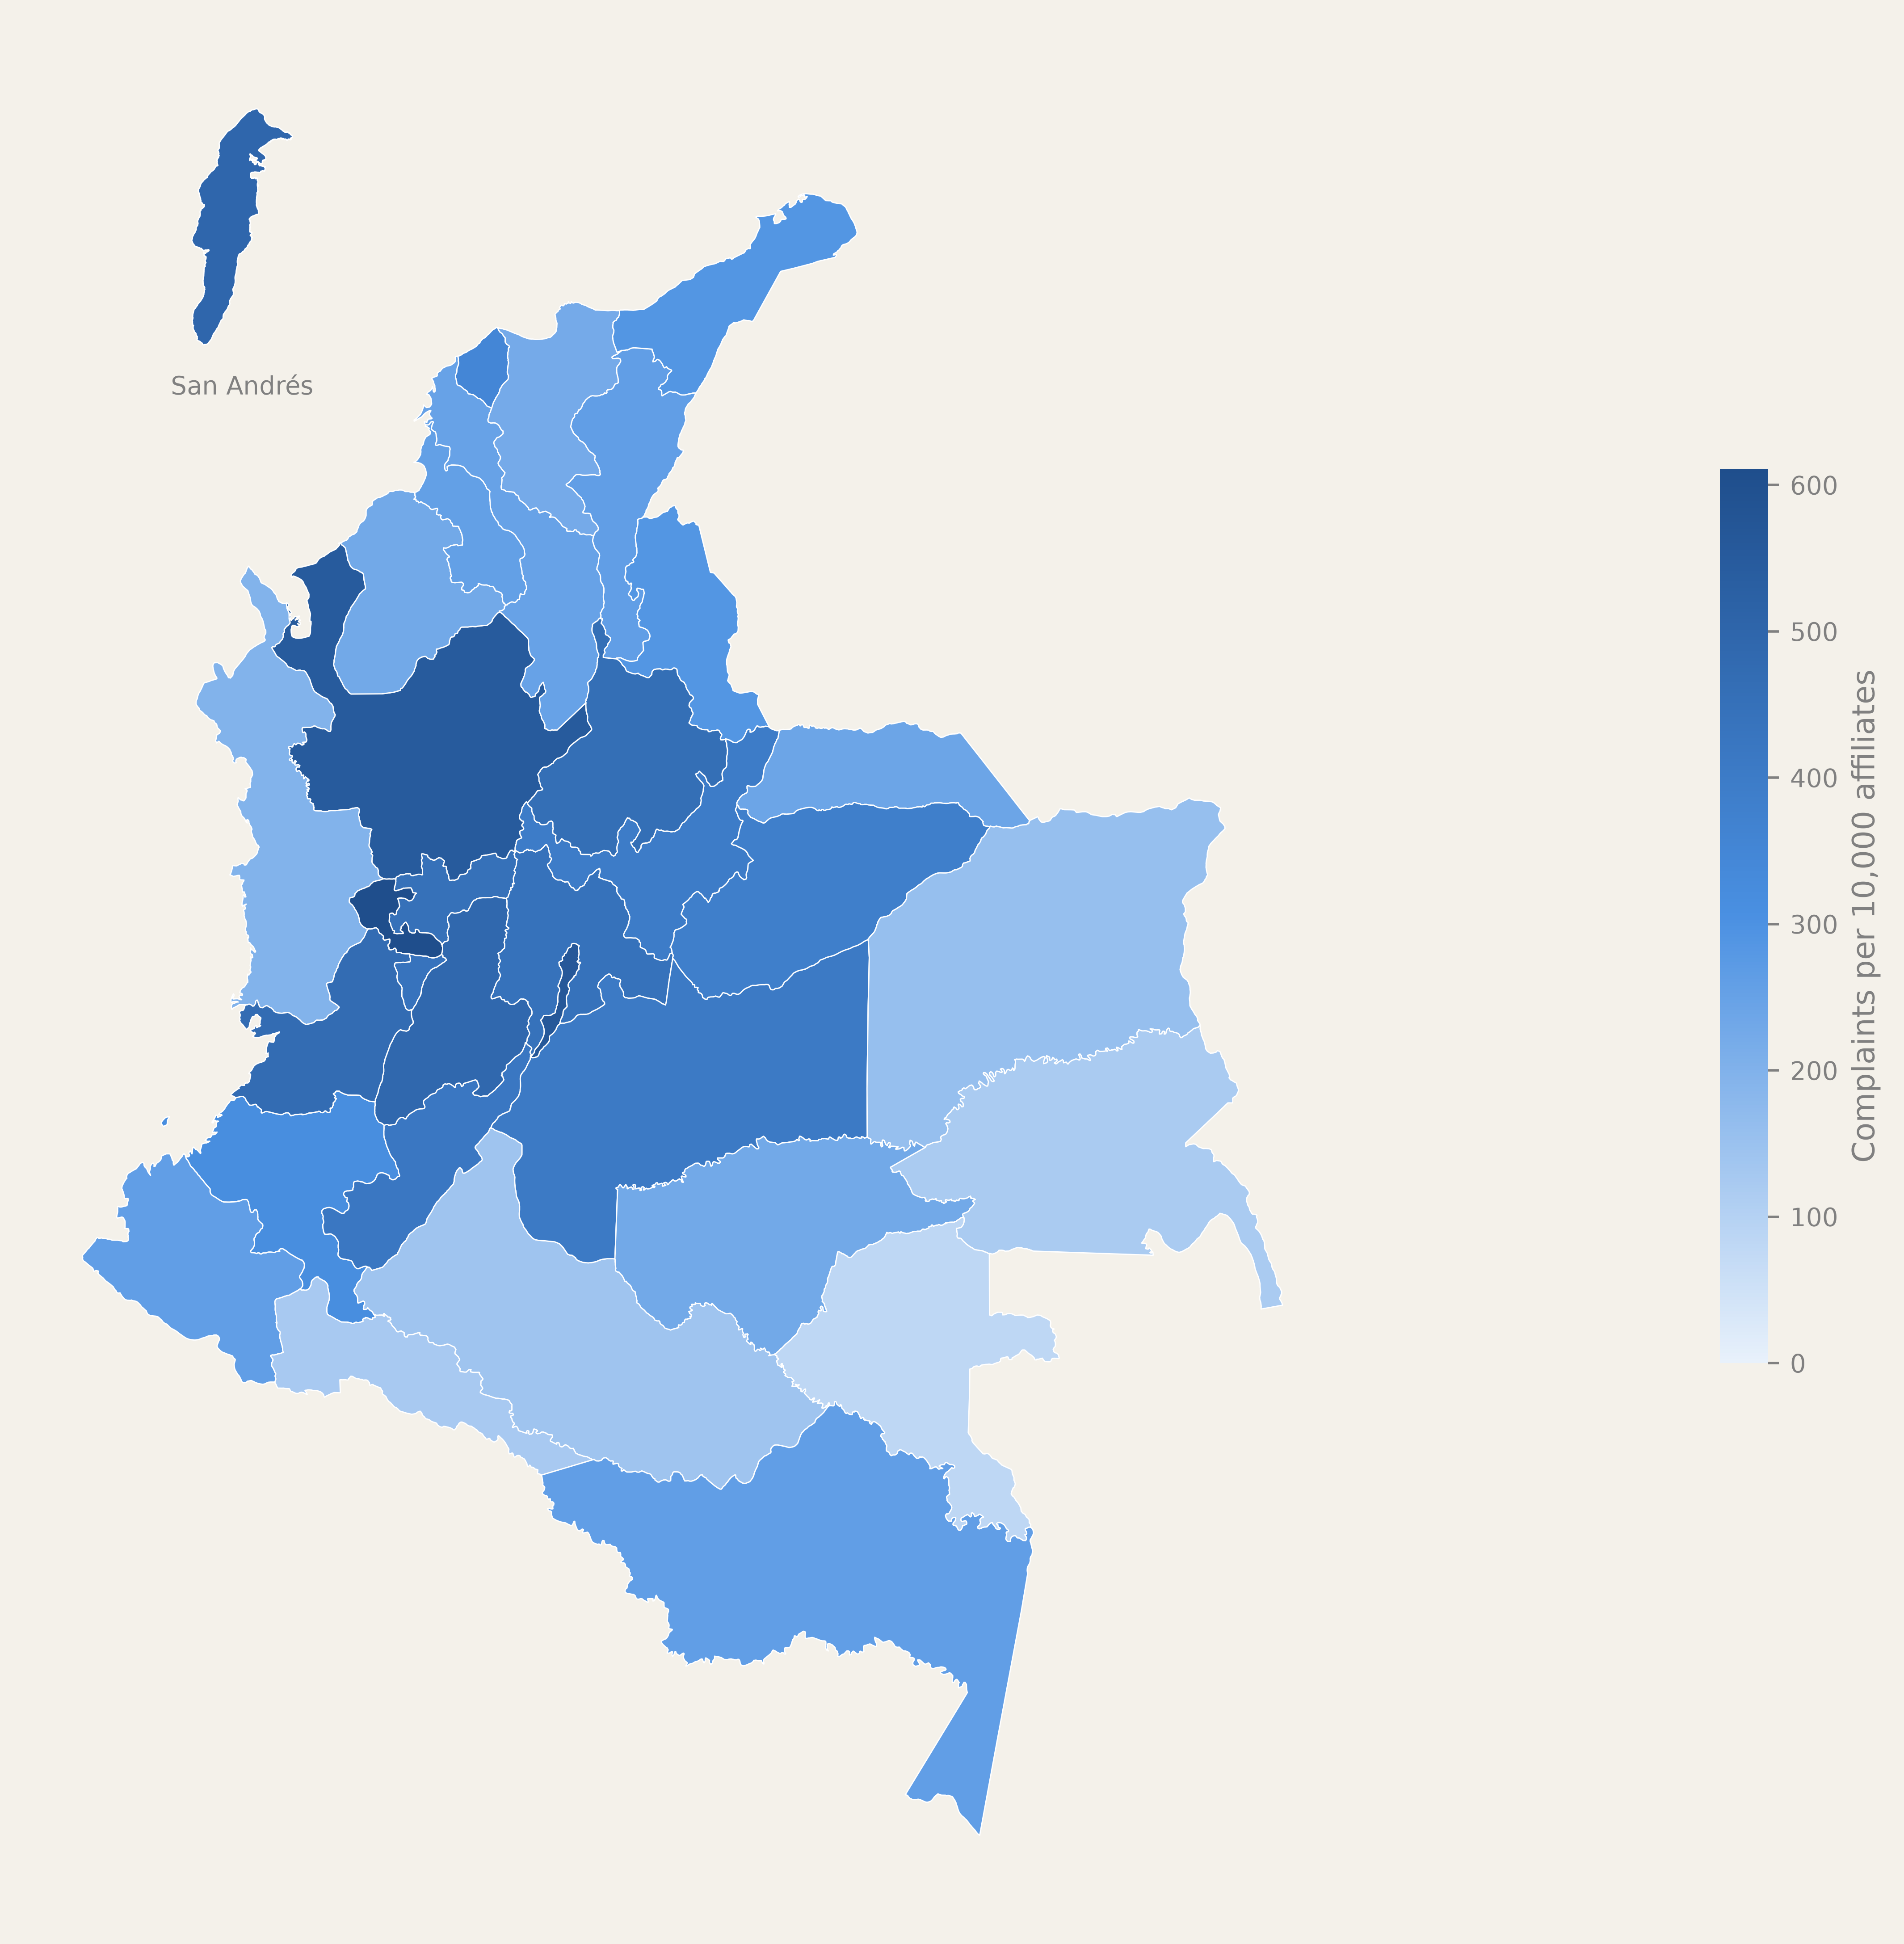

In [10]:
missing_color = "#D3D3D3"
cmap = LinearSegmentedColormap.from_list("blue", ["#e8f1fb", blue, "#1f4e8c"])
norm = Normalize(vmin=0, vmax=vmax)

sanandres_box = {"lon": (-79.0, -75.9), "lat": (10.9, 13.3)}


def exterior_rings(geometry: dict) -> list:
    if geometry["type"] == "Polygon":
        return [geometry["coordinates"][0]]
    return [poly[0] for poly in geometry["coordinates"]]


def fit_box(rings: list, box: dict) -> list:
    """Uniform scale + center rings into a target lon/lat box (preserve aspect)."""
    xs = [x for r in rings for x, _ in r]
    ys = [y for r in rings for _, y in r]
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    bx0, bx1 = box["lon"]
    by0, by1 = box["lat"]
    scale = min((bx1 - bx0) / (x1 - x0), (by1 - by0) / (y1 - y0))
    ox = bx0 + ((bx1 - bx0) - (x1 - x0) * scale) / 2
    oy = by0 + ((by1 - by0) - (y1 - y0) * scale) / 2
    return [[(ox + (x - x0) * scale, oy + (y - y0) * scale) for x, y in r]
            for r in rings]


fig, ax = plt.subplots(figsize=(10.8, 10), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

patches, colors = [], []
for feat in geo["features"]:
    code = feat["properties"]["DPTO"]
    val = dept_rates.get(code)
    color = missing_color if pd.isna(val) else cmap(norm(val))
    rings = exterior_rings(feat["geometry"])
    if code == "88":
        def bbox_area(r):
            xs = [x for x, _ in r]; ys = [y for _, y in r]
            return (max(xs) - min(xs)) * (max(ys) - min(ys))
        main = max(rings, key=bbox_area)
        rings = fit_box([main], sanandres_box)
    for ring in rings:
        patches.append(Polygon(ring, closed=True))
        colors.append(color)

ax.add_collection(PatchCollection(
    patches, facecolor=colors, edgecolor="white", linewidth=0.4))
ax.autoscale_view()
ax.set_aspect("equal")
ax.axis("off")
ax.set_position([0.02, 0.05, 0.78, 0.85])

ax.text(-77.45, 10.6, "San Andrés", fontsize=8, color="gray",
        ha="center", va="top")

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
cax = fig.add_axes([0.84, 0.3, 0.02, 0.4])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Complaints per 10,000 affiliates", fontsize=10, color="gray")
cbar.ax.tick_params(labelsize=8, colors="gray")
cbar.outline.set_visible(False)

plt.show()

## Top 5 EPS by complaint rate · 2025

Rate = complaints per 10,000 affiliates, year-to-date. EPS without a published
rate (subsidised entrants operating only since mid-2025) are excluded.

## Load & rank

In [8]:
eps = pd.read_csv("./data/eps.csv", encoding="utf-8")

top5 = {
    reg: eps[eps["regimen"] == reg].nlargest(5, "tasa_10000").reset_index(drop=True)
    for reg in ["CONTRIBUTIVO", "SUBSIDIADO"]
}

## Render

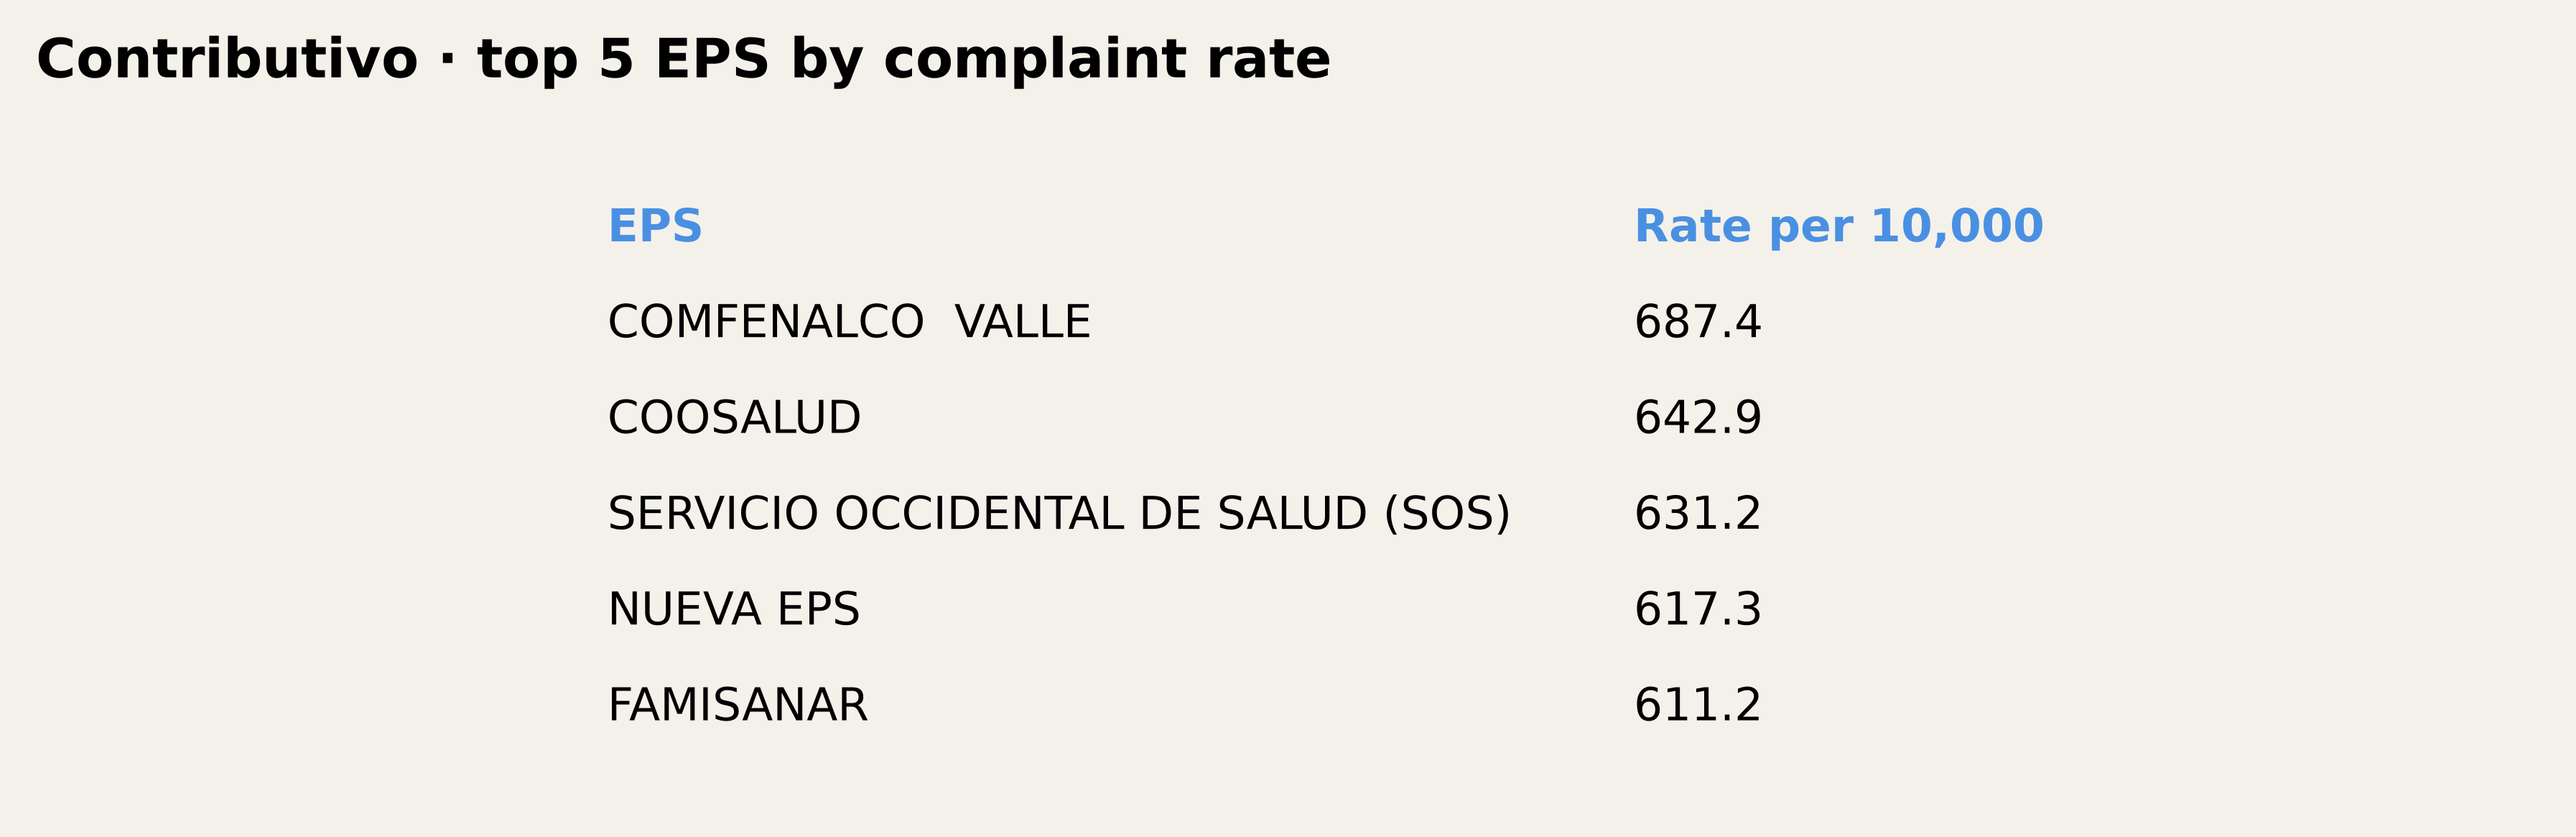

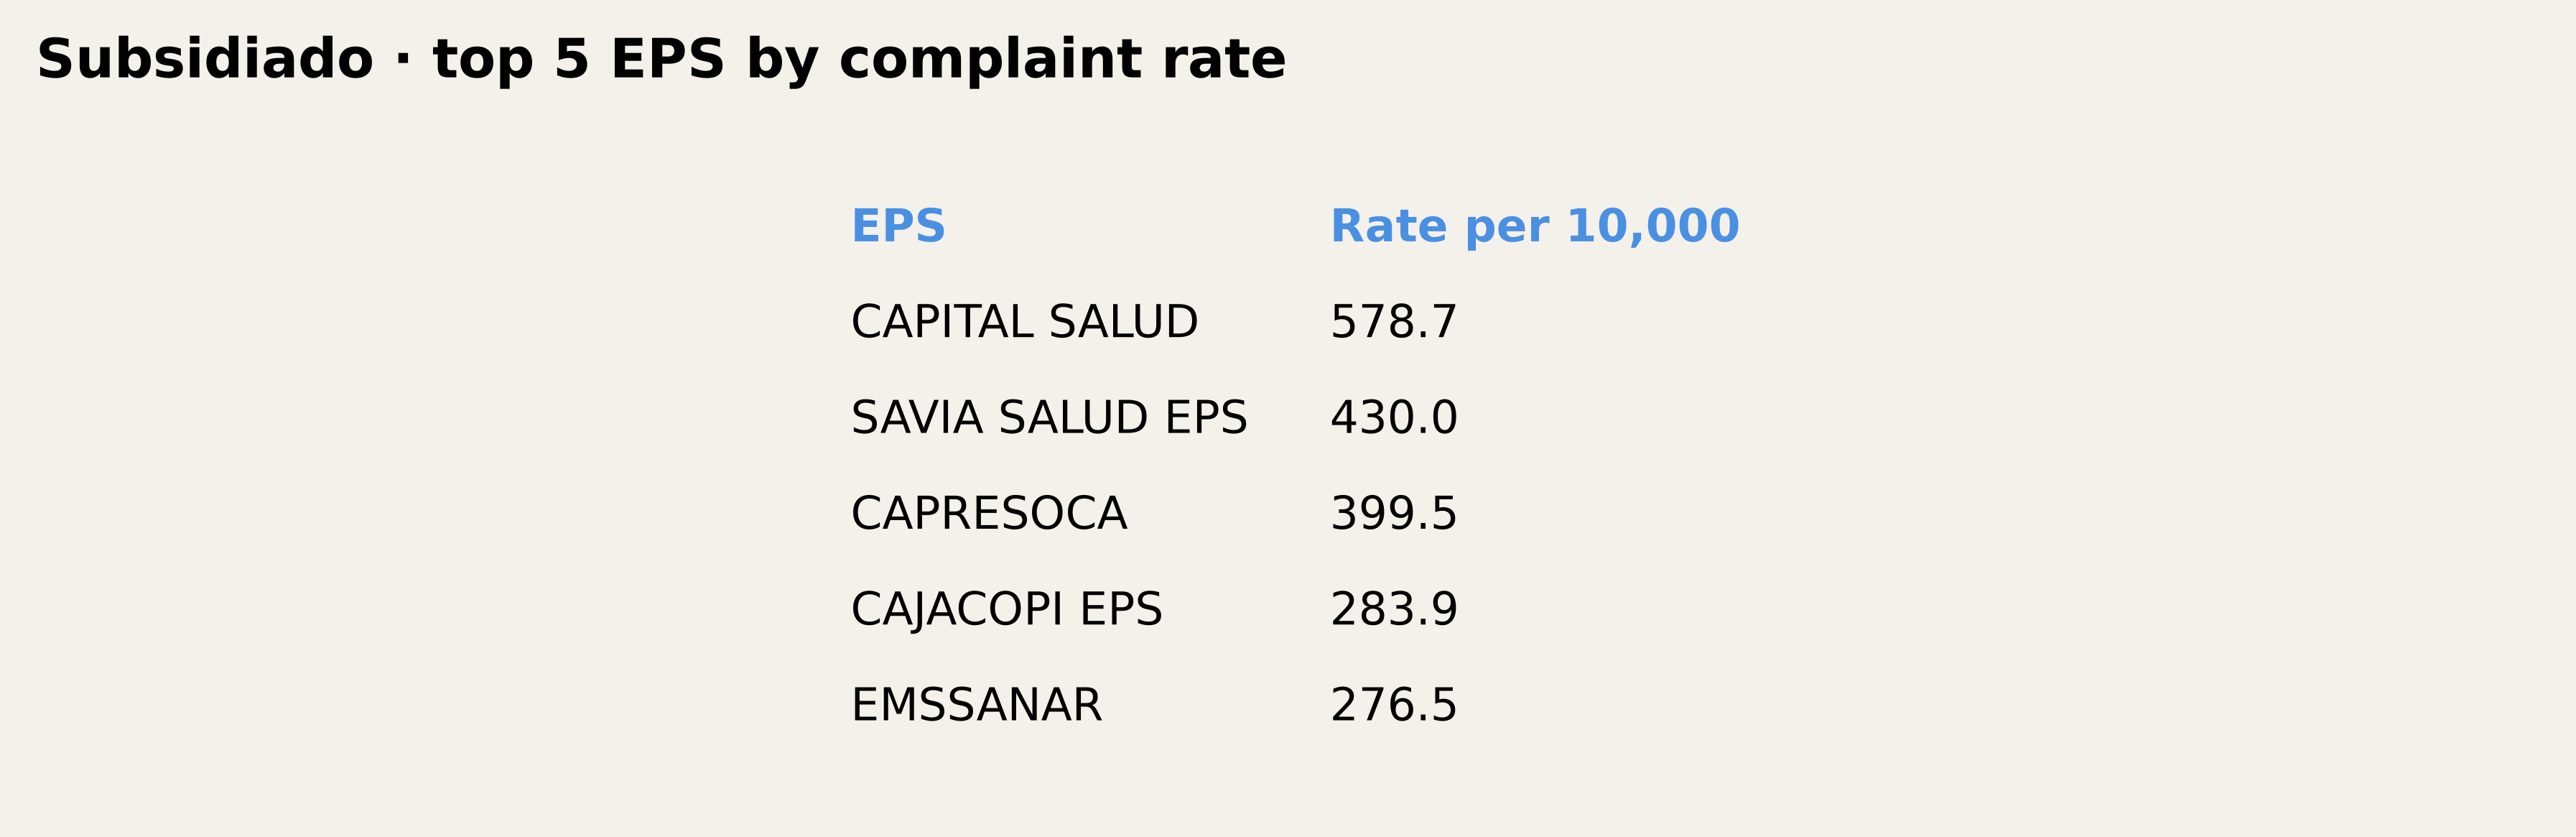

In [9]:
def render_eps_table(ranked: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(9.0, 2.4), dpi=500)
    fig.patch.set_facecolor(background)
    fig.subplots_adjust(top=0.82, bottom=0.05)
    ax.axis("off")

    cells = [[row["eps"], f"{row['tasa_10000']:.1f}"] for _, row in ranked.iterrows()]
    table = ax.table(
        cellText=cells,
        colLabels=["EPS", "Rate per 10,000"],
        cellLoc="left",
        colLoc="left",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.auto_set_column_width([0, 1])
    table.scale(1, 1.6)
    for (r, _), cell in table.get_celld().items():
        cell.set_edgecolor("none")
        cell.set_facecolor(background)
        if r == 0:
            cell.set_text_props(weight="bold", color=blue)

    ax.set_title(title, loc="left", fontsize=11, weight="bold", pad=12)
    plt.show()


for reg, ranked in top5.items():
    render_eps_table(ranked, f"{reg.title()} · top 5 EPS by complaint rate")